In [ ]:
weights_path_final_3_gap_dmt = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_241002_3_GAP-014-0.764-0.740.pth"
weights_path_final_resnet18_dmft = "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_resnet18-003-0.993-0.993.pth"
weights_path_final_5_gap_ft =  "final_checkpoints/baseline_rejection_ensemble/prot-DM_time_binary_classificator_241002_5_GAP-060-0.973-0.948.pth"

r1_params = {
    'conv_mlp': {
        'path': '/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/baseline_rejection_ensemble/prot-run_embedding_3_GAP_conv_mlp_lr1.05e-05_wd0.00e+00_drop0.0_channels64_extraFalse_pool7_hidden64_worker2_trial3-042-0.712-0.635.pth',
        'kwargs': {'model_name': 'conv_mlp', 'cnn_channels': 64, 'extra_conv': False, 'pool_size': 7, 'hidden_dim': 64}
    }
}

r2_params = {
    'conv_mlp': {
        'path': "/cephfs/users/oleksjuk/MA/WP2-1/single_pulse_classifier_training/final_checkpoints/baseline_rejection_ensemble/prot-run_embedding_r2_conv_mlp_lr4.51e-05_wd0.00e+00_drop0.2_channels64_extraTrue_pool7_hidden128_worker13_trial6-035-0.825-0.842.pth",
        'kwargs': {'model_name': 'conv_mlp', 'cnn_channels': 64, 'extra_conv': True, 'pool_size': 7, 'hidden_dim': 128}
    }
}

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

import training_models
import training
from embedding_processing_models import build_embedding_processing
from DMTimeShardDataset import DMTimeShardDataset

device = "cuda" if torch.cuda.is_available() else "cpu"

# ========== Load Models ==========
dataset_cfg = {
    'output_dir': '/cephfs/users/oleksjuk/MA/WP2-1/DM_time_dataset_creator/outputs', 
    'prefix': 'B0531+21_59000_48386'
}

print('Loading models...')
small_model = training_models.models_htable['DM_time_binary_classificator_241002_3_GAP'](256, mode='dmt', dropout=False, device=device).to(device)
small_model.load_state_dict(torch.load(weights_path_final_3_gap_dmt, map_location=device)['model_state_dict'])
small_model.eval()

mid_model = training_models.models_htable['DM_time_binary_classificator_241002_5_GAP'](256, mode='ft', dropout=False, device=device).to(device)
mid_model.load_state_dict(torch.load(weights_path_final_5_gap_ft, map_location=device)['model_state_dict'])
mid_model.eval()

large_model = training_models.models_htable['DM_time_binary_classificator_resnet18'](256, mode="dmft", dropout=False, device=device).to(device)
large_model.load_state_dict(torch.load(weights_path_final_resnet18_dmft, map_location=device)["model_state_dict"])
large_model.eval()

# ========== Load Rejectors ==========
def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ("model_state_dict", "state_dict", "model"):
            value = checkpoint.get(key)
            if isinstance(value, dict):
                return value
    return checkpoint

def get_rejector_state_dict(ckpt):
    state_dict = extract_state_dict(ckpt)
    if not isinstance(state_dict, dict):
        return state_dict
    clean_dict = {}
    for k, v in state_dict.items():
        if k.startswith("1.net."):
            clean_dict[k.replace("1.net.", "net.")] = v
        elif k.startswith("1."):
            clean_dict[k.replace("1.", "")] = v
        elif k.startswith("embedding_processing."):
            clean_dict[k.replace("embedding_processing.", "")] = v
    return clean_dict or state_dict

# R1 rejector
r1_ckpt_path = r1_params['conv_mlp']['path']
r1_kwargs = r1_params['conv_mlp']['kwargs']
r1_model, r1_hook = build_embedding_processing(in_channels=12, **r1_kwargs)
r1_model.to(device)
r1_model.eval()
r1_ckpt = torch.load(r1_ckpt_path, map_location=device)
r1_model.load_state_dict(get_rejector_state_dict(r1_ckpt))

# R2 rejector
r2_ckpt_path = r2_params['conv_mlp']['path']
r2_kwargs = r2_params['conv_mlp']['kwargs']
r2_model, r2_hook = build_embedding_processing(in_channels=12, **r2_kwargs)
r2_model.to(device)
r2_model.eval()
r2_ckpt = torch.load(r2_ckpt_path, map_location=device)
r2_model.load_state_dict(get_rejector_state_dict(r2_ckpt))

print('Loading validation dataset...')
pulse_val_dataset = DMTimeShardDataset(dataset_cfg, use_freq_time=True, split="val")
pulse_val_dataset.labels = training.label_encoding(pulse_val_dataset.labels.astype(object))

pulse_val_loader = DataLoader(
    pulse_val_dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=2,
)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading models...
Loading validation dataset...
Converting string labels to numeric: ['Artefact' 'Pulse'] -> [0, 1]


In [3]:
# ========== Collect Predictions and Scores ==========
print('Computing predictions and rejector scores...')
all_r1_scores = []
all_r2_scores = []
all_small_preds = []
all_mid_preds = []
all_large_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(pulse_val_loader):
        labels = batch['label'].to(device)

        # f_small
        small_input = small_model.features(batch)
        if small_input.dim() == 3:
            small_input = small_input.unsqueeze(0)
        small_logits = small_model.classifier(small_input)
        small_pred = small_logits.argmax(dim=1)

        # R1 scores
        r1_features = getattr(small_model, r1_hook)(small_input)
        if r1_features.dim() == 3:
            r1_features = r1_features.unsqueeze(0)
        elif r1_hook == 'pooled_features' and r1_features.dim() == 1:
            r1_features = r1_features.unsqueeze(0)
        r1_logits = r1_model(r1_features)
        r1_scores = torch.softmax(r1_logits, dim=1)[:, 1].detach()

        # f_mid
        mid_input = mid_model.features(batch)
        if mid_input.dim() == 3:
            mid_input = mid_input.unsqueeze(0)
        mid_logits = mid_model.classifier(mid_input)
        mid_pred = mid_logits.argmax(dim=1)

        # R2 scores
        r2_features = getattr(mid_model, r2_hook)(mid_input)
        if r2_features.dim() == 3:
            r2_features = r2_features.unsqueeze(0)
        elif r2_hook == 'pooled_features' and r2_features.dim() == 1:
            r2_features = r2_features.unsqueeze(0)
        r2_logits = r2_model(r2_features)
        r2_scores = torch.softmax(r2_logits, dim=1)[:, 1].detach()

        # f_large
        large_input = large_model.features(batch)
        if large_input.dim() == 3:
            large_input = large_input.unsqueeze(0)
        large_logits = large_model.classifier(large_input)
        large_pred = large_logits.argmax(dim=1)

        all_r1_scores.append(r1_scores.cpu())
        all_r2_scores.append(r2_scores.cpu())
        all_small_preds.append(small_pred.cpu())
        all_mid_preds.append(mid_pred.cpu())
        all_large_preds.append(large_pred.cpu())
        all_labels.append(labels.cpu())

r1_scores_np = torch.cat(all_r1_scores).numpy()
r2_scores_np = torch.cat(all_r2_scores).numpy()
small_preds_np = torch.cat(all_small_preds).numpy()
mid_preds_np = torch.cat(all_mid_preds).numpy()
large_preds_np = torch.cat(all_large_preds).numpy()
labels_np = torch.cat(all_labels).numpy()

print(f"Collected {len(labels_np)} samples")

Computing predictions and rejector scores...


100%|██████████| 168/168 [01:40<00:00,  1.67it/s]


Collected 172032 samples


In [4]:
# ========== Grid Search over R1 and R2 Thresholds ==========
print('Computing accuracy grid...')
r1_thresholds = np.linspace(0.0, 1.0, 21)  # 21 thresholds for R1
r2_thresholds = np.linspace(0.0, 1.0, 21)  # 21 thresholds for R2

accuracy_grid = np.zeros((len(r1_thresholds), len(r2_thresholds)))

for i, r1_t in enumerate(r1_thresholds):
    for j, r2_t in enumerate(r2_thresholds):
        # R1: Accept -> f_small, Reject -> consider R2
        r1_reject_mask = r1_scores_np >= r1_t
        r1_accept_mask = ~r1_reject_mask

        # R2: only applies to samples rejected by R1
        r2_reject_mask = r1_reject_mask & (r2_scores_np >= r2_t)
        r2_accept_mask = r1_reject_mask & ~r2_reject_mask

        # Routing decision
        y_pred = small_preds_np.copy()
        y_pred[r2_accept_mask] = mid_preds_np[r2_accept_mask]
        y_pred[r2_reject_mask] = large_preds_np[r2_reject_mask]

        accuracy = (y_pred == labels_np).mean()
        accuracy_grid[i, j] = accuracy

print("Accuracy grid computed!")

Computing accuracy grid...
Accuracy grid computed!


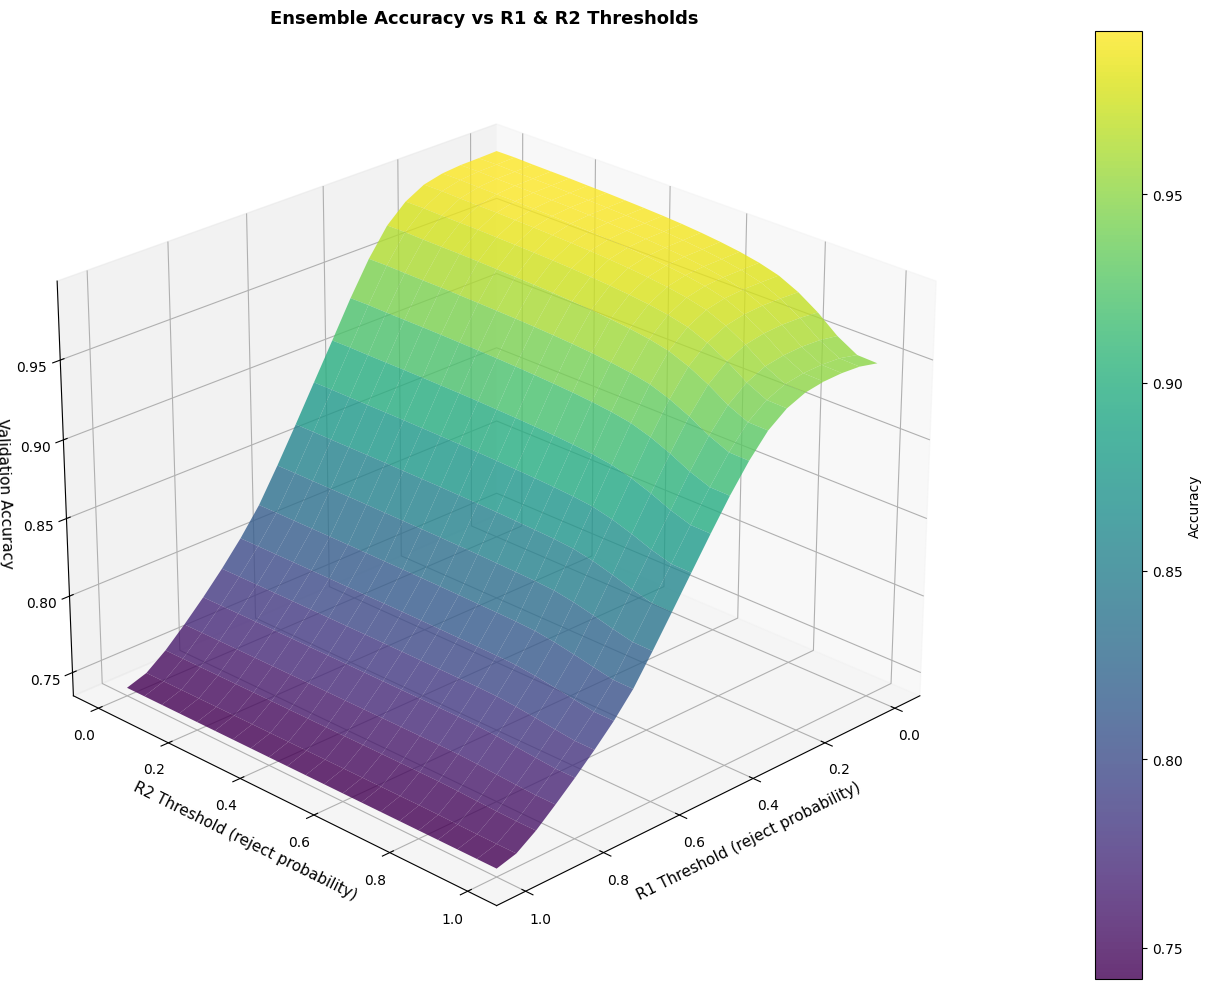


=== Best Configuration ===
R1 Threshold: 0.0000
R2 Threshold: 0.0500
Validation Accuracy: 0.9935


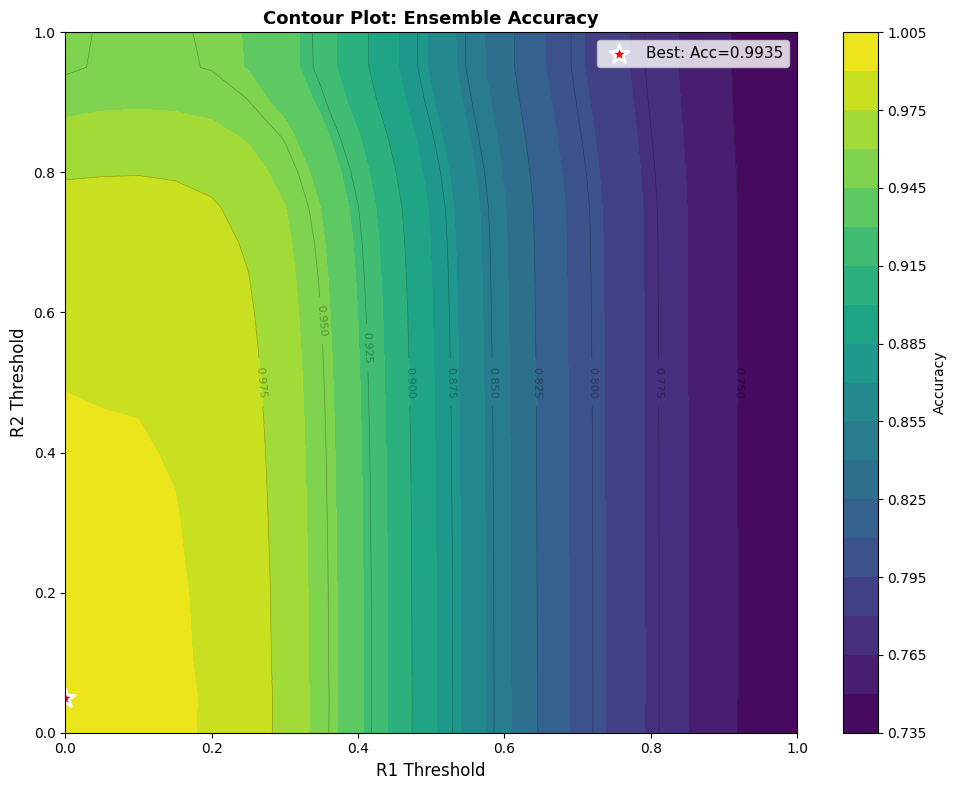

In [5]:
# ========== 3D Surface Plot ==========
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Create meshgrid
R1_grid, R2_grid = np.meshgrid(r1_thresholds, r2_thresholds, indexing='ij')

# Plot surface
surf = ax.plot_surface(R1_grid, R2_grid, accuracy_grid, cmap='viridis', alpha=0.8, edgecolor='none')

ax.set_xlabel('R1 Threshold (reject probability)', fontsize=11)
ax.set_ylabel('R2 Threshold (reject probability)', fontsize=11)
ax.set_zlabel('Validation Accuracy', fontsize=11)
ax.set_title('Ensemble Accuracy vs R1 & R2 Thresholds', fontsize=13, fontweight='bold')

# Add colorbar
fig.colorbar(surf, ax=ax, pad=0.1, label='Accuracy')

# Rotate view for better visibility
ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

# ========== Find Best Configuration ==========
best_idx = np.unravel_index(np.argmax(accuracy_grid), accuracy_grid.shape)
best_r1_t = r1_thresholds[best_idx[0]]
best_r2_t = r2_thresholds[best_idx[1]]
best_acc = accuracy_grid[best_idx]

print(f"\n=== Best Configuration ===")
print(f"R1 Threshold: {best_r1_t:.4f}")
print(f"R2 Threshold: {best_r2_t:.4f}")
print(f"Validation Accuracy: {best_acc:.4f}")

# ========== Contour Plot ==========
fig, ax = plt.subplots(figsize=(10, 8))
contour = ax.contourf(R1_grid, R2_grid, accuracy_grid, levels=20, cmap='viridis')
contour_lines = ax.contour(R1_grid, R2_grid, accuracy_grid, levels=10, colors='black', alpha=0.3, linewidths=0.5)
ax.clabel(contour_lines, inline=True, fontsize=8)

# Mark best point
ax.scatter([best_r1_t], [best_r2_t], color='red', s=200, marker='*', edgecolors='white', linewidths=2, label=f'Best: Acc={best_acc:.4f}')

ax.set_xlabel('R1 Threshold', fontsize=12)
ax.set_ylabel('R2 Threshold', fontsize=12)
ax.set_title('Contour Plot: Ensemble Accuracy', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

cbar = fig.colorbar(contour, ax=ax, label='Accuracy')
plt.tight_layout()
plt.show()

Latency grid computed!


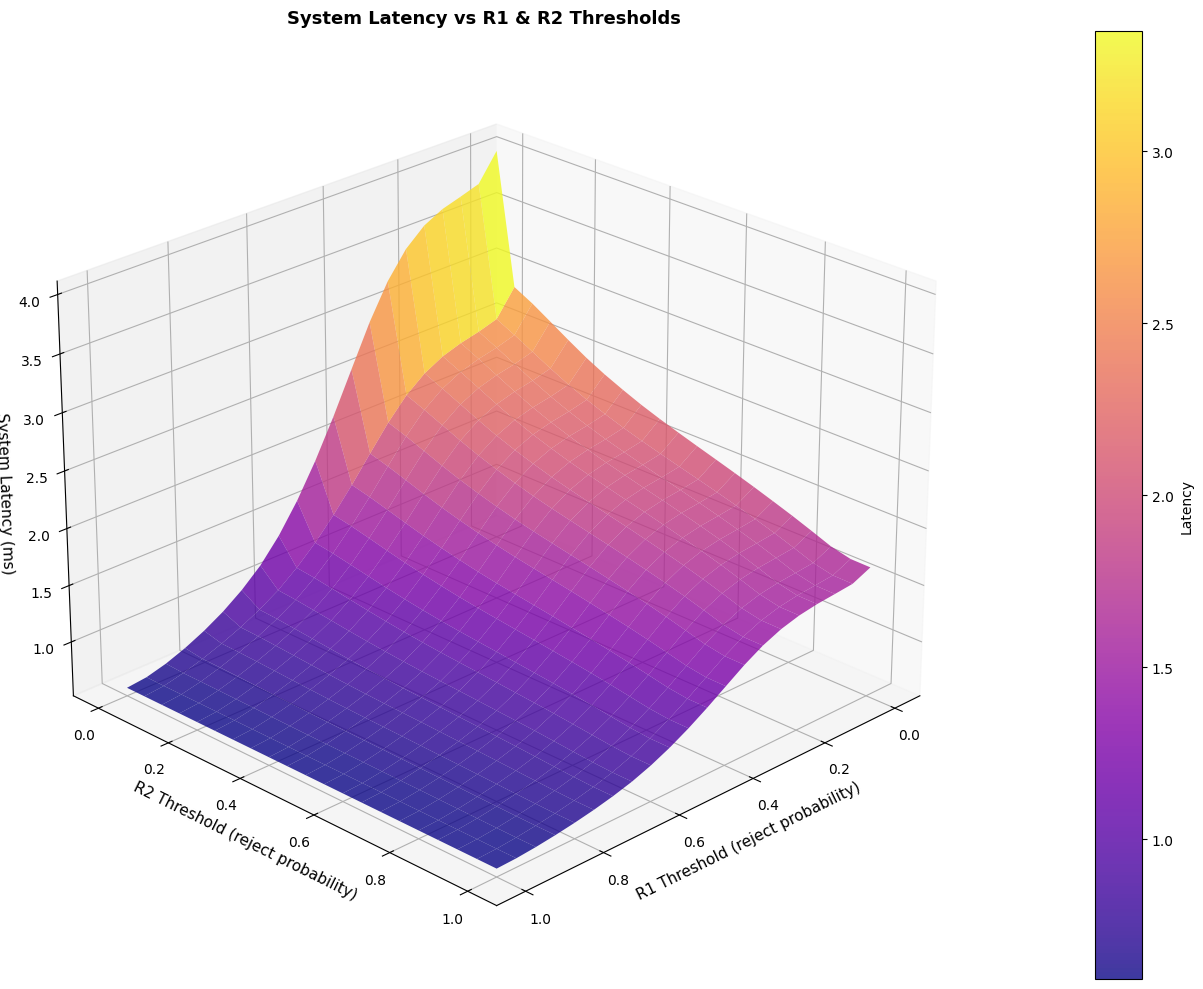

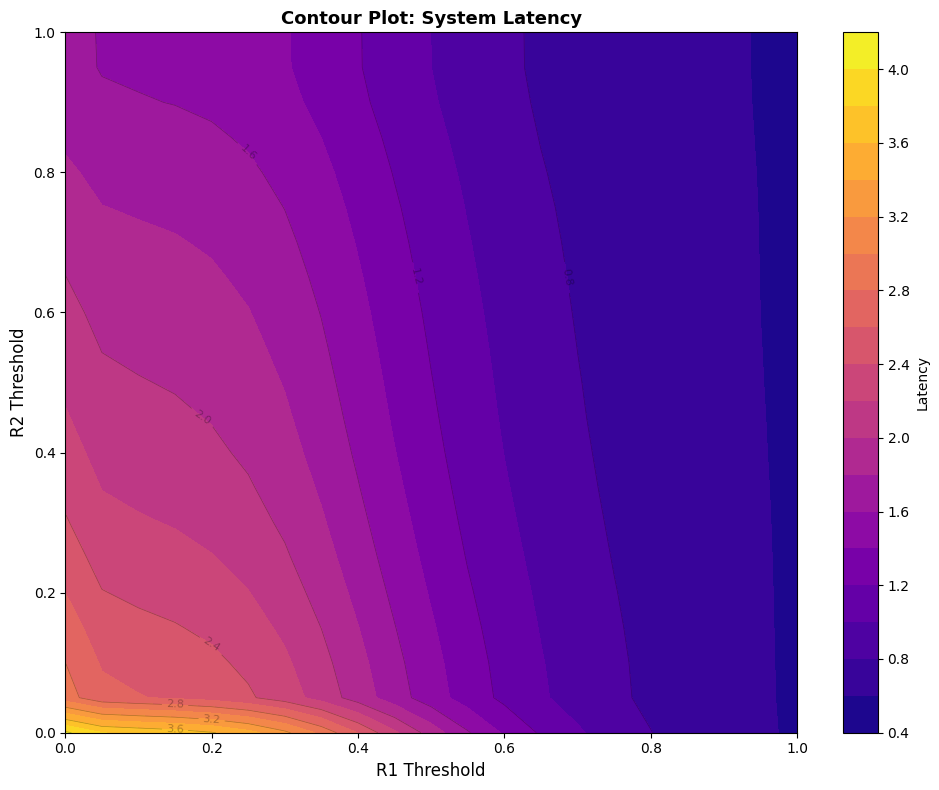

In [7]:
# ========== Calculate Latency Grid ==========
latency_grid = np.zeros_like(accuracy_grid)

for i, r1_t in enumerate(r1_thresholds):
    # R1 reject mask on ALL data
    r1_reject_mask = r1_scores_np > r1_t
    # R1 reject rate (x_1) over the entire dataset
    x_1 = np.mean(r1_reject_mask)
    
    for j, r2_t in enumerate(r2_thresholds):
        # r2_scores_np is evaluated for all samples, but R2 is only active if R1 rejects.
        # R2 conditional reject rate (x_2) is measured ONLY among those rejected by R1.
        if x_1 > 0:
            x_2 = np.mean(r2_scores_np[r1_reject_mask] > r2_t)
        else:
            x_2 = 0.0
            
        # Formula: y = 1 * 0.21 + 1 * 0.25 + (1 - x_1) * 0.13 + x_1 * (0.51 + 0.21 + 0.38+((1-x_2) * 0.10) + x_2 * 2.48)
        y = 1 * 0.21 + 1 * 0.25 + (1 - x_1) * 0.13 + x_1 * (0.51 + 0.21 + 0.38+((1-x_2) * 0.10) + x_2 * 2.48)
        latency_grid[i, j] = y

print("Latency grid computed!")

# ========== 3D Surface Plot for Latency ==========
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot surface (using R1_grid and R2_grid from previous cell)
surf_lat = ax.plot_surface(R1_grid, R2_grid, latency_grid, cmap='plasma', alpha=0.8, edgecolor='none')

ax.set_xlabel('R1 Threshold (reject probability)', fontsize=11)
ax.set_ylabel('R2 Threshold (reject probability)', fontsize=11)
ax.set_zlabel('System Latency (ms)', fontsize=11) # assuming ms or arbitrary units
ax.set_title('System Latency vs R1 & R2 Thresholds', fontsize=13, fontweight='bold')

# Add colorbar
fig.colorbar(surf_lat, ax=ax, pad=0.1, label='Latency')

# Rotate view
ax.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

# ========== Latency Contour Plot (Optional) ==========
fig, ax = plt.subplots(figsize=(10, 8))
contour_lat = ax.contourf(R1_grid, R2_grid, latency_grid, levels=20, cmap='plasma')
contour_lat_lines = ax.contour(R1_grid, R2_grid, latency_grid, levels=10, colors='black', alpha=0.3, linewidths=0.5)
ax.clabel(contour_lat_lines, inline=True, fontsize=8)

ax.set_xlabel('R1 Threshold', fontsize=12)
ax.set_ylabel('R2 Threshold', fontsize=12)
ax.set_title('Contour Plot: System Latency', fontsize=13, fontweight='bold')

cbar_lat = fig.colorbar(contour_lat, ax=ax, label='Latency')
plt.tight_layout()
plt.show()

In [ ]:
# ========== Additional Plot: Latency vs actual Reject Rates ==========
r1_reject_rate_grid = np.zeros_like(latency_grid)
r2_reject_rate_grid = np.zeros_like(latency_grid)

for i, r1_t in enumerate(r1_thresholds):
    r1_reject_mask = r1_scores_np > r1_t
    x_1 = np.mean(r1_reject_mask)

    for j, r2_t in enumerate(r2_thresholds):
        x_2 = (
            np.mean(r2_scores_np[r1_reject_mask] > r2_t)
            if np.any(r1_reject_mask) else 0.0
        )
        r1_reject_rate_grid[i, j] = x_1
        r2_reject_rate_grid[i, j] = x_2

# R2 is conditional on R1, so the rate pairs do not form a rectangular grid.
# Remove duplicate rate pairs before triangular interpolation.
rate_points = np.column_stack((
    r1_reject_rate_grid.ravel(),
    r2_reject_rate_grid.ravel(),
))
_, unique_idx = np.unique(rate_points, axis=0, return_index=True)
r1_rates_plot = rate_points[unique_idx, 0]
r2_rates_plot = rate_points[unique_idx, 1]
latencies_plot = latency_grid.ravel()[unique_idx]

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
surf_rate = ax.plot_trisurf(
    r1_rates_plot, r2_rates_plot, latencies_plot,
    cmap='plasma', alpha=0.8, edgecolor='none',
)
ax.set_xlabel('R1 Reject Rate', fontsize=11)
ax.set_ylabel('R2 Conditional Reject Rate', fontsize=11)
ax.set_zlabel('System Latency (ms)', fontsize=11)
ax.set_title('System Latency vs R1 & R2 Reject Rates', fontsize=13, fontweight='bold')
fig.colorbar(surf_rate, ax=ax, pad=0.1, label='Latency')
ax.view_init(elev=25, azim=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
contour_rate = ax.tricontourf(
    r1_rates_plot, r2_rates_plot, latencies_plot, levels=20, cmap='plasma'
)
contour_rate_lines = ax.tricontour(
    r1_rates_plot, r2_rates_plot, latencies_plot, levels=10,
    colors='black', alpha=0.3, linewidths=0.5,
)
ax.clabel(contour_rate_lines, inline=True, fontsize=8)
ax.set_xlabel('R1 Reject Rate', fontsize=12)
ax.set_ylabel('R2 Conditional Reject Rate', fontsize=12)
ax.set_title('Contour Plot: System Latency vs Reject Rates', fontsize=13, fontweight='bold')
fig.colorbar(contour_rate, ax=ax, label='Latency')
plt.tight_layout()
plt.show()
